In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchaudio
from torchaudio import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights

In [2]:
os.makedirs('./data', exist_ok=True)
train_data = datasets.SPEECHCOMMANDS(root='./data', download=True, subset='training')
valid_data = datasets.SPEECHCOMMANDS(root='./data', download=True, subset='validation')
test_data = datasets.SPEECHCOMMANDS(root='./data', download=True, subset='testing')

100%|██████████| 2.26G/2.26G [00:16<00:00, 147MB/s]


In [3]:
ALL_LABELS = sorted(list(set([i[2] for i in train_data + valid_data + test_data])))
label_to_index = {lbl: ind for ind, lbl in enumerate(ALL_LABELS)}
label = ALL_LABELS

In [4]:
len(label)

35

In [5]:
mel_transform = transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=1024,
    hop_length=160,
    n_mels=80
)
amp_to_db = transforms.AmplitudeToDB()

In [6]:
freq_mask = transforms.FrequencyMasking(freq_mask_param=15)
time_mask = transforms.TimeMasking(time_mask_param=35)

In [7]:
TARGET_TIME_FRAMES = 101 # Стандартная длина 1-секундного аудио при hop_length=160

def process_audio_batch(audio_batch, is_train=False):
    spectrograms, classes = [], []
    for waveform, sample_rate, lbl, *_ in audio_batch:
        # Вычисление мел-спектрограммы и переведение в дБ
        spec = amp_to_db(mel_transform(waveform)).squeeze(0)

        # Обрезка или паддинг до фиксированной длины по времени
        if spec.shape[1] > TARGET_TIME_FRAMES:
            spec = spec[:, :TARGET_TIME_FRAMES]
        elif spec.shape[1] < TARGET_TIME_FRAMES:
            pad_amount = TARGET_TIME_FRAMES - spec.shape[1]
            spec = F.pad(spec, (0, pad_amount))

        # Аугментация Spectrogram Masking
        if is_train:
            spec = freq_mask(spec)
            spec = time_mask(spec)

        spectrograms.append(spec)
        classes.append(label_to_index[lbl])

    # Формируем тензор: (Batch, 1, Mel_bins, Time_frames)
    spectrograms = torch.stack(spectrograms).unsqueeze(1)
    targets = torch.tensor(classes)
    return spectrograms, targets

In [8]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, collate_fn=lambda b: process_audio_batch(b, is_train=True))
valid_loader = DataLoader(valid_data, batch_size=64, collate_fn=lambda b: process_audio_batch(b, is_train=False))
test_loader = DataLoader(test_data, batch_size=64, collate_fn=lambda b: process_audio_batch(b, is_train=False))

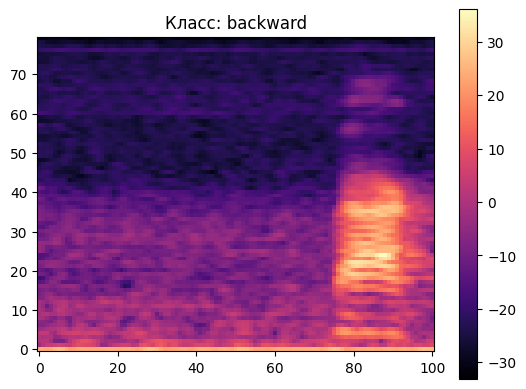

In [9]:
waveform, sample_rate, lbl, *_ = train_data[0]
spec = amp_to_db(mel_transform(waveform)).squeeze(0)
plt.imshow(spec.numpy(), cmap='magma', origin='lower')
plt.title(f'Класс: {lbl}')
plt.colorbar()
plt.show()

In [10]:
class CheckAudio(nn.Module):
    def __init__(self, num_classes=len(ALL_LABELS)):
        super().__init__()
        # Загружаем ResNet18
        self.model = resnet18(weights=ResNet18_Weights.DEFAULT)
        # Меняем первый сверточный слой под 1 входной канал вместо 3 (RGB)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Выходной слой под число наших классов
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [12]:
model_CheckAudio = CheckAudio().to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


In [13]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_CheckAudio.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

In [14]:
for epoch in range(20):
    model_CheckAudio.train()
    total_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model_CheckAudio(x_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    print(f'Эпоха: {epoch + 1}, Потери: {round(total_loss, 2)}')

Эпоха: 1, Потери: 1283.12
Эпоха: 2, Потери: 707.8
Эпоха: 3, Потери: 591.52
Эпоха: 4, Потери: 525.47
Эпоха: 5, Потери: 460.18
Эпоха: 6, Потери: 424.43
Эпоха: 7, Потери: 379.22
Эпоха: 8, Потери: 344.67
Эпоха: 9, Потери: 311.3
Эпоха: 10, Потери: 272.1
Эпоха: 11, Потери: 246.42
Эпоха: 12, Потери: 228.68
Эпоха: 13, Потери: 207.17
Эпоха: 14, Потери: 193.92
Эпоха: 15, Потери: 189.56
Эпоха: 16, Потери: 183.43
Эпоха: 17, Потери: 184.63
Эпоха: 18, Потери: 191.2
Эпоха: 19, Потери: 187.88
Эпоха: 20, Потери: 196.31


In [15]:
model_CheckAudio.eval()
correct, total = 0, 0

with torch.no_grad():
    for x, y in valid_loader:  # Исправлено: вместо 'valid' используем 'valid_loader'
        x, y = x.to(device), y.to(device)
        prediction = model_CheckAudio(x).argmax(dim=1)
        total += y.size(0)
        correct += (prediction == y).sum().item()

acc = correct * 100 / total
print(f'Точность на валидации: {round(acc, 2)}%')

Точность на валидации: 97.15%


In [16]:
def get_accuracy(data_loader):
    model_CheckAudio.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            y_pred = model_CheckAudio(x)
            prediction = torch.argmax(y_pred, dim=1)
            total += y.size(0)
            correct += (prediction == y).sum().item()
    return round(correct * 100 / total, 2)

# Исправлено: передаем train_loader и test_loader вместо train и test
print(f'train score: {get_accuracy(train_loader)}%')
print(f'test score: {get_accuracy(test_loader)}%')

train score: 95.54%
test score: 97.03%


In [17]:
torch.save(model_CheckAudio.state_dict(), 'model_CheckAudio_SyntheticSpeechCommands.pth')
torch.save(label, 'label_SyntheticSpeechCommands.pth')

from google.colab import files
files.download('model_CheckAudio_SyntheticSpeechCommands.pth')
files.download('label_SyntheticSpeechCommands.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
print(label)

['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']
